# Predicción de Miopía en Estudiantes de Medicina
## Universidad de Navarra

### Objetivo:
Predecir 4 variables relacionadas con la miopía:
1. **M**: Clasificación binaria (SI/NO) - ¿Tiene miopía?
2. **MM**: Clasificación binaria (SI/NO) - ¿Tiene miopía magna?
3. **COMBO**: Clasificación multi-clase (M, MM, C) - Tipo de condición
4. **DCOMBO**: Clasificación multi-clase (M1, M2, MM, C) - Clasificación detallada

## 1. Importar Librerías

In [33]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('default')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Cargar Datos

In [34]:
X_train = pd.read_csv('X_train.csv')
Y_train = pd.read_csv('Y_train.csv')
X_test = pd.read_csv('X_test.csv')

print(f"Training: {X_train.shape}, Labels: {Y_train.shape}, Test: {X_test.shape}")

Training: (132, 49), Labels: (132, 4), Test: (24, 49)


## 3. Análisis Básico de Etiquetas

In [35]:
print("Distribución de clases en training:\n")
for col in Y_train.columns:
    counts = Y_train[col].value_counts()
    ratio = counts.max() / counts.min()
    print(f"{col}: {counts.to_dict()}")
    print("-" * 50)

Distribución de clases en training:

M: {'SI': 88, 'NO': 44}
--------------------------------------------------
MM: {'NO': 122, 'SI': 10}
--------------------------------------------------
Combo: {'M': 70, 'C': 44, 'MM': 18}
--------------------------------------------------
DCombo: {'C': 44, 'M1': 39, 'M2': 31, 'MM': 18}
--------------------------------------------------


## 4. Preprocesamiento Robusto

In [36]:
class RobustPreprocessor:
    """
    Preprocesador que guarda estadísticas de training para aplicar a test.
    Arregla el bug de asignación de columnas del imputer.
    """
    
    def __init__(self):
        self.numeric_imputers = {}  # Guardar medianas por columna
        self.label_encoders = {}    # Guardar encoders
        self.feature_names = None
        self.columns_to_drop = ['fecha']
        
    def fit(self, X):
        """Entrenar con conjunto de training"""
        X_proc = X.copy()
        
        # 1. Eliminar columnas no útiles
        for col in self.columns_to_drop:
            if col in X_proc.columns:
                X_proc = X_proc.drop(col, axis=1)
        
        # 2. Identificar tipos
        numeric_cols = X_proc.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_proc.select_dtypes(include=['object']).columns.tolist()
        
        # 3. Calcular y guardar medianas
        for col in numeric_cols:
            median_val = X_proc[col].median()
            if pd.isna(median_val):
                median_val = 0
            self.numeric_imputers[col] = median_val
        
        # 4. Entrenar encoders
        for col in categorical_cols:
            X_proc[col].fillna('Unknown', inplace=True)
            le = LabelEncoder()
            le.fit(X_proc[col].astype(str))
            self.label_encoders[col] = le
        
        self.feature_names = X_proc.columns.tolist()
        print(f"Preprocesador entrenado: {len(self.feature_names)} características")
        return self
    
    def transform(self, X):
        """Transformar usando estadísticas guardadas"""
        X_proc = X.copy()
        
        # 1. Eliminar columnas
        for col in self.columns_to_drop:
            if col in X_proc.columns:
                X_proc = X_proc.drop(col, axis=1)
        
        # 2. Identificar tipos
        numeric_cols = X_proc.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_proc.select_dtypes(include=['object']).columns.tolist()
        
        # 3. Imputar valores numéricos - COLUMNA POR COLUMNA para evitar el bug
        for col in numeric_cols:
            if col in self.numeric_imputers:
                X_proc[col].fillna(self.numeric_imputers[col], inplace=True)
            else:
                X_proc[col].fillna(0, inplace=True)
            X_proc[col].replace([np.inf, -np.inf], 0, inplace=True)
        
        # 4. Codificar categóricas
        for col in categorical_cols:
            X_proc[col].fillna('Unknown', inplace=True)
            if col in self.label_encoders:
                le = self.label_encoders[col]
                X_proc[col] = X_proc[col].apply(
                    lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else 0
                )
            else:
                X_proc[col] = 0
        
        # 5. Limpieza final
        X_proc = X_proc.fillna(0)
        for col in X_proc.select_dtypes(include=[np.number]).columns:
            X_proc[col] = X_proc[col].replace([np.inf, -np.inf], 0)
        
        return X_proc
    
    def fit_transform(self, X):
        """Entrenar y transformar"""
        self.fit(X)
        return self.transform(X)

## 5. Aplicar Preprocesamiento

In [37]:
# Crear y entrenar
preprocessor = RobustPreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"\nTrain: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"NaN en train: {X_train_proc.isnull().sum().sum()}")
print(f"NaN en test: {X_test_proc.isnull().sum().sum()}")

Preprocesador entrenado: 48 características


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\enriq\AppData\Local\Temp\ipykernel_2824\1091705136.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_proc[col].fillna('Unknown', inplace=True)
C:\Users\enriq\AppData\Local\Temp\ipykernel_2824\1091705136.py:35: FutureWarning: A value is trying to be


Train: (132, 48), Test: (24, 48)
NaN en train: 0
NaN en test: 0


## 6. Estandarización

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled = scaler.transform(X_test_proc)

print(f"   Media: {X_train_scaled.mean():.6f}")
print(f"   Std: {X_train_scaled.std():.6f}")

   Media: 0.000000
   Std: 0.989529


## 7. Train/Validation Split

In [39]:
# Crear splits estratificados para cada etiqueta
data_splits = {}

for label in Y_train.columns:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, Y_train[label].values,
        test_size=0.2, random_state=42,
        stratify=Y_train[label].values
    )
    data_splits[label] = {'X_train': X_tr, 'X_val': X_val, 'y_train': y_tr, 'y_val': y_val}
    print(f"{label}: Train={X_tr.shape[0]}, Val={X_val.shape[0]}")

M: Train=105, Val=27
MM: Train=105, Val=27
Combo: Train=105, Val=27
DCombo: Train=105, Val=27


## 8. Definir Modelos y Grids de Hiperparámetros

In [40]:
# Grids reducidos para velocidad
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'SVM': {
        'model': SVC(random_state=42, class_weight='balanced', probability=True),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'kernel': ['rbf', 'linear']
        }
    }
}


## 9. Función de Entrenamiento con GridSearchCV

In [41]:
def train_and_optimize(X_train, y_train, X_val, y_val, label_name, is_binary=True):
    """
    Entrena modelos con GridSearchCV y evalúa con múltiples métricas.
    """
    print(f"\n{'='*80}")
    print(f"OPTIMIZANDO: {label_name}")
    print("="*80)
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scoring = 'f1' if is_binary else 'f1_weighted'
    
    best_score = -np.inf
    best_model = None
    best_model_name = None
    all_results = {}
    
    for model_name, model_info in param_grids.items():
        print(f"\n{model_name}...")
        
        grid_search = GridSearchCV(
            estimator=model_info['model'],
            param_grid=model_info['params'],
            cv=cv, scoring=scoring, n_jobs=-1, verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        
        # Evaluar en validación
        val_score = f1_score(y_val, grid_search.predict(X_val), 
                            average='binary' if is_binary else 'weighted',
                            pos_label='SI' if is_binary else None)
        
        print(f"   CV: {grid_search.best_score_:.4f} | Val: {val_score:.4f}")
        print(f"   Params: {grid_search.best_params_}")
        
        all_results[model_name] = {
            'model': grid_search.best_estimator_,
            'cv_score': grid_search.best_score_,
            'val_score': val_score,
            'params': grid_search.best_params_
        }
        
        if val_score > best_score:
            best_score = val_score
            best_model = grid_search.best_estimator_
            best_model_name = model_name
    
    print(f"\nMEJOR: {best_model_name} | F1: {best_score:.4f}")
    return best_model, all_results, best_model_name

## 10. Entrenar Modelos

In [42]:
models = {}
training_results = {}
best_model_names = {}

for label in Y_train.columns:
    X_tr = data_splits[label]['X_train']
    X_val = data_splits[label]['X_val']
    y_tr = data_splits[label]['y_train']
    y_val = data_splits[label]['y_val']
    
    is_binary = len(np.unique(y_tr)) == 2
    
    best_model, results, best_name = train_and_optimize(
        X_tr, y_tr, X_val, y_val, label, is_binary
    )
    
    models[label] = best_model
    training_results[label] = results
    best_model_names[label] = best_name



OPTIMIZANDO: M

Random Forest...


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


   CV: nan | Val: 0.8571
   Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Logistic Regression...
   CV: nan | Val: 0.8571
   Params: {'C': 0.1, 'solver': 'lbfgs'}

SVM...
   CV: nan | Val: 0.5714
   Params: {'C': 0.1, 'kernel': 'rbf'}

MEJOR: Random Forest | F1: 0.8571

OPTIMIZANDO: MM

Random Forest...


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


   CV: nan | Val: 0.0000
   Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Logistic Regression...
   CV: nan | Val: 0.5714
   Params: {'C': 0.1, 'solver': 'lbfgs'}

SVM...
   CV: nan | Val: 0.0000
   Params: {'C': 0.1, 'kernel': 'rbf'}

MEJOR: Logistic Regression | F1: 0.5714

OPTIMIZANDO: Combo

Random Forest...


C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


   CV: 0.7105 | Val: 0.6997
   Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Logistic Regression...
   CV: 0.6563 | Val: 0.7421
   Params: {'C': 10.0, 'solver': 'lbfgs'}

SVM...
   CV: 0.6954 | Val: 0.8119
   Params: {'C': 0.1, 'kernel': 'linear'}

MEJOR: SVM | F1: 0.8119

OPTIMIZANDO: DCombo

Random Forest...
   CV: 0.5160 | Val: 0.6664
   Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Logistic Regression...
   CV: 0.4498 | Val: 0.6634
   Params: {'C': 0.1, 'solver': 'lbfgs'}

SVM...
   CV: 0.5088 | Val: 0.7073
   Params: {'C': 0.1, 'kernel': 'linear'}

MEJOR: SVM | F1: 0.7073


## 11. Evaluación en Validación

In [43]:
def evaluate_model(model, X_val, y_val, label_name, is_binary=True):
    """Evalúa modelo con múltiples métricas"""
    y_pred = model.predict(X_val)
    
    # Predicciones de probabilidad
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_val)
        else:
            y_proba = None
    except:
        y_proba = None
    
    # Métricas
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_val, y_pred)
    
    if is_binary:
        metrics['precision'] = precision_score(y_val, y_pred, pos_label='SI', zero_division=0)
        metrics['recall'] = recall_score(y_val, y_pred, pos_label='SI', zero_division=0)
        metrics['f1'] = f1_score(y_val, y_pred, pos_label='SI', zero_division=0)
        
        # ROC-AUC
        if y_proba is not None:
            y_proba_pos = y_proba[:, 1] if len(y_proba.shape) == 2 else y_proba
            y_val_binary = (y_val == 'SI').astype(int)
            metrics['roc_auc'] = roc_auc_score(y_val_binary, y_proba_pos)
    else:
        metrics['precision'] = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        metrics['recall'] = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        metrics['f1'] = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{label_name}:")
    for metric, value in metrics.items():
        print(f"   {metric.capitalize():12s}: {value:.4f}")
    
    return metrics, y_pred, y_proba

# Evaluar todos
evaluations = {}
for label in Y_train.columns:
    X_val = data_splits[label]['X_val']
    y_val = data_splits[label]['y_val']
    is_binary = len(np.unique(y_val)) == 2
    
    metrics, y_pred, y_proba = evaluate_model(models[label], X_val, y_val, label, is_binary)
    evaluations[label] = {'metrics': metrics, 'y_pred': y_pred, 'y_proba': y_proba, 'y_true': y_val}


M:
   Accuracy    : 0.8148
   Precision   : 0.8824
   Recall      : 0.8333
   F1          : 0.8571
   Roc_auc     : 0.8889

MM:
   Accuracy    : 0.8889
   Precision   : 0.4000
   Recall      : 1.0000
   F1          : 0.5714
   Roc_auc     : 1.0000

Combo:
   Accuracy    : 0.8148
   Precision   : 0.8304
   Recall      : 0.8148
   F1          : 0.8119

DCombo:
   Accuracy    : 0.7037
   Precision   : 0.7463
   Recall      : 0.7037
   F1          : 0.7073


## 12. Curvas ROC y Precision-Recall (SOLO ESTAS)

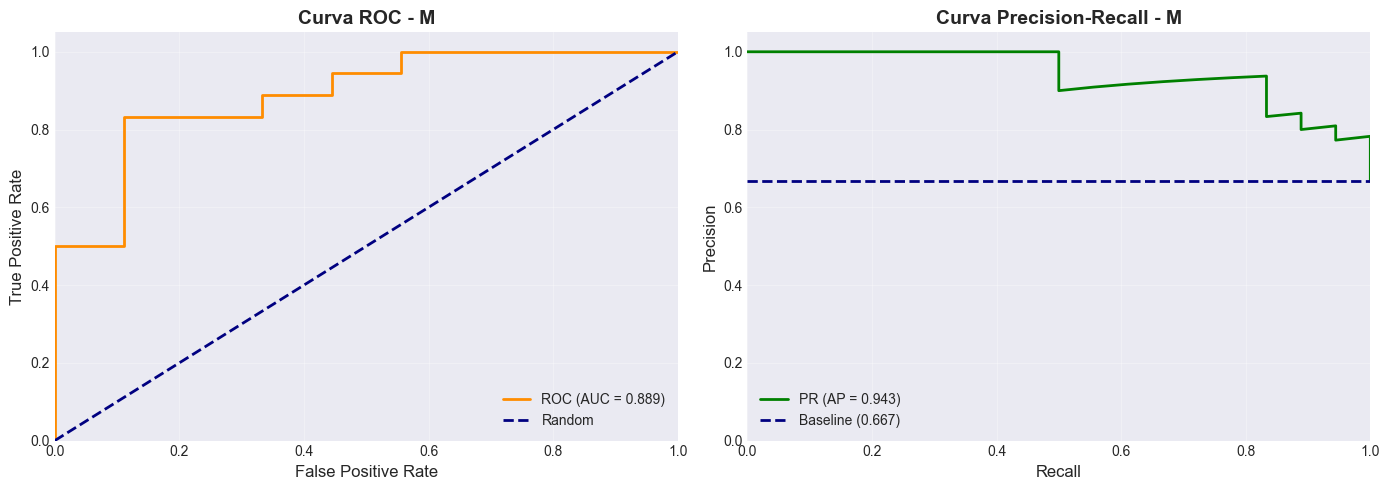


M:
   ROC-AUC: 0.8889
   Average Precision: 0.9435


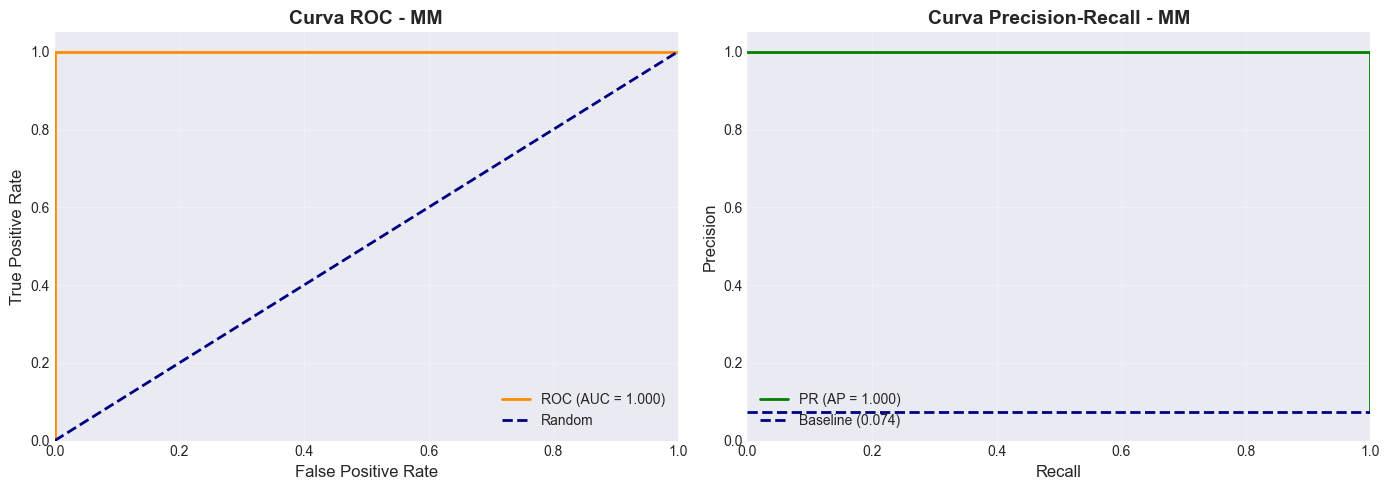


MM:
   ROC-AUC: 1.0000
   Average Precision: 1.0000


In [44]:
def plot_roc_and_pr_curves(evaluations, label_name):
    """Plotear curvas ROC y Precision-Recall"""
    eval_data = evaluations[label_name]
    y_true = eval_data['y_true']
    y_proba = eval_data['y_proba']
    
    # Solo para binaria con probabilidades
    if y_proba is None or len(np.unique(y_true)) != 2:
        print(f"Curvas no disponibles para {label_name} (multi-clase o sin probabilidades)")
        return
    
    # Convertir a binario
    y_true_binary = (y_true == 'SI').astype(int)
    y_proba_pos = y_proba[:, 1] if len(y_proba.shape) == 2 else y_proba
    
    # Crear figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Curva ROC
    fpr, tpr, _ = roc_curve(y_true_binary, y_proba_pos)
    roc_auc = roc_auc_score(y_true_binary, y_proba_pos)
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title(f'Curva ROC - {label_name}', fontsize=14, fontweight='bold')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)
    
    # 2. Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true_binary, y_proba_pos)
    avg_precision = average_precision_score(y_true_binary, y_proba_pos)
    
    ax2.plot(recall, precision, color='green', lw=2, label=f'PR (AP = {avg_precision:.3f})')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title(f'Curva Precision-Recall - {label_name}', fontsize=14, fontweight='bold')
    ax2.legend(loc="lower left")
    ax2.grid(alpha=0.3)
    
    # Baseline
    baseline = y_true_binary.sum() / len(y_true_binary)
    ax2.axhline(y=baseline, color='navy', linestyle='--', lw=2, 
                label=f'Baseline ({baseline:.3f})')
    ax2.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{label_name}:")
    print(f"   ROC-AUC: {roc_auc:.4f}")
    print(f"   Average Precision: {avg_precision:.4f}")

# Plotear solo para M y MM (binarias)
for label in ['M', 'MM']:
    if label in Y_train.columns:
        plot_roc_and_pr_curves(evaluations, label)

## 13. Predicciones en Test

In [45]:
print("\n GENERANDO PREDICCIONES EN TEST")
print("="*80)

predictions = {}
for label in Y_train.columns:
    pred = models[label].predict(X_test_scaled)
    predictions[label] = pred
    print(f"   ✓ {label}")

predictions_df = pd.DataFrame(predictions)
print("\nPredicciones completadas")


 GENERANDO PREDICCIONES EN TEST
   ✓ M
   ✓ MM
   ✓ Combo
   ✓ DCombo

Predicciones completadas


## 14. Mostrar Predicciones

In [46]:
print("\nPREDICCIONES:")
display(predictions_df)

print("\nDISTRIBUCIÓN:")
for col in predictions_df.columns:
    print(f"\n{col}:")
    for clase, count in predictions_df[col].value_counts().items():
        pct = count / len(predictions_df) * 100
        print(f"   {clase}: {count} ({pct:.1f}%)")


PREDICCIONES:


,M,MM,Combo,DCombo
0,SI,NO,MM,MM
1,SI,NO,C,C
2,SI,SI,MM,M2
3,SI,NO,M,M1
4,SI,NO,M,M1
5,SI,NO,C,M1
6,SI,NO,M,M1
7,SI,NO,M,M2
8,NO,NO,M,M1
9,SI,SI,MM,M1



DISTRIBUCIÓN:

M:
   SI: 20 (83.3%)
   NO: 4 (16.7%)

MM:
   NO: 21 (87.5%)
   SI: 3 (12.5%)

Combo:
   M: 13 (54.2%)
   C: 7 (29.2%)
   MM: 4 (16.7%)

DCombo:
   M1: 10 (41.7%)
   C: 7 (29.2%)
   M2: 5 (20.8%)
   MM: 2 (8.3%)


## 15. Resumen Final

In [47]:
print("\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)

print(f"\nDataset: {len(X_train)} train, {len(data_splits['M']['X_val'])} val, {len(X_test)} test")

print(f"\nModelos seleccionados:")
for label in Y_train.columns:
    print(f"   {label}: {best_model_names[label]}")

print(f"\nRendimiento en validación:")
for label in Y_train.columns:
    metrics = evaluations[label]['metrics']
    print(f"\n   {label}:")
    for metric, value in metrics.items():
        print(f"      {metric.capitalize():12s}: {value:.4f}")



RESUMEN FINAL

Dataset: 132 train, 27 val, 24 test

Modelos seleccionados:
   M: Random Forest
   MM: Logistic Regression
   Combo: SVM
   DCombo: SVM

Rendimiento en validación:

   M:
      Accuracy    : 0.8148
      Precision   : 0.8824
      Recall      : 0.8333
      F1          : 0.8571
      Roc_auc     : 0.8889

   MM:
      Accuracy    : 0.8889
      Precision   : 0.4000
      Recall      : 1.0000
      F1          : 0.5714
      Roc_auc     : 1.0000

   Combo:
      Accuracy    : 0.8148
      Precision   : 0.8304
      Recall      : 0.8148
      F1          : 0.8119

   DCombo:
      Accuracy    : 0.7037
      Precision   : 0.7463
      Recall      : 0.7037
      F1          : 0.7073
